# Previsão de Aprovação de Crédito
**Disciplina de Inteligência Artificial — Professor Munif — Unicesumar 2026**

**Integrantes:**
- Matheus Felipe Campioto Catenacci — RA: 22014137-2
- André Felipe Ferrari de Azevedo — RA: 22120196-2

## 1. Instalação e Importação de Bibliotecas

In [19]:
# Instalação (necessário apenas no Colab)
!pip install scikit-learn pandas numpy matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score
)
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


## 2. Carregamento do Dataset
**Dataset: German Credit Data (UCI Machine Learning Repository)**
- 1000 registros de clientes
- 20 atributos (idade, renda, histórico de crédito, etc.)
- Variável alvo: Risk (bom pagador = 'good' / mau pagador = 'bad')

In [20]:
from sklearn.datasets import fetch_openml

dataset = fetch_openml(name='credit-g', version=1, as_frame=True)
df_raw = dataset.frame

df = pd.DataFrame()
df['Age'] = df_raw['age']
df['Sex'] = 'male'
df['Job'] = 2
df['Housing'] = df_raw['housing']
df['Saving accounts'] = df_raw['savings_status']
df['Checking account'] = df_raw['checking_status']
df['Credit amount'] = df_raw['credit_amount']
df['Duration'] = df_raw['duration']
df['Purpose'] = df_raw['purpose']
df['Risk'] = df_raw['class'].map({'good': 'good', 'bad': 'bad'})

print('Dataset carregado via OpenML!')
print(f'Shape: {df.shape}')
print(f'Risk: {df["Risk"].value_counts().to_dict()}')
df.head()

Dataset carregado via OpenML!
Shape: (1000, 10)
Risk: {'good': 700, 'bad': 300}


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,no known savings,<0,1169,6,radio/tv,good
1,22,male,2,own,<100,0<=X<200,5951,48,radio/tv,bad
2,49,male,2,own,<100,no checking,2096,12,education,good
3,45,male,2,for free,<100,<0,7882,42,furniture/equipment,good
4,53,male,2,for free,<100,<0,4870,24,new car,bad


## 3. Análise Exploratória dos Dados

In [21]:
print('=== Informações do Dataset ===')
print(df.info())
print('\n=== Valores Nulos ===')
print(df.isnull().sum())
print('\n=== Estatísticas Descritivas ===')
df.describe()

=== Informações do Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Age               1000 non-null   int64   
 1   Sex               1000 non-null   object  
 2   Job               1000 non-null   int64   
 3   Housing           1000 non-null   category
 4   Saving accounts   1000 non-null   category
 5   Checking account  1000 non-null   category
 6   Credit amount     1000 non-null   int64   
 7   Duration          1000 non-null   int64   
 8   Purpose           1000 non-null   category
 9   Risk              1000 non-null   category
dtypes: category(5), int64(4), object(1)
memory usage: 45.1+ KB
None

=== Valores Nulos ===
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose            

,Age,Job,Credit amount,Duration
count,1000.000000,1000.0,1000.000000,1000.000000
mean,35.546000,2.0,3271.258000,20.903000
std,11.375469,0.0,2822.736876,12.058814
min,19.000000,2.0,250.000000,4.000000
25%,27.000000,2.0,1365.500000,12.000000
50%,33.000000,2.0,2319.500000,18.000000
75%,42.000000,2.0,3972.250000,24.000000
max,75.000000,2.0,18424.000000,72.000000


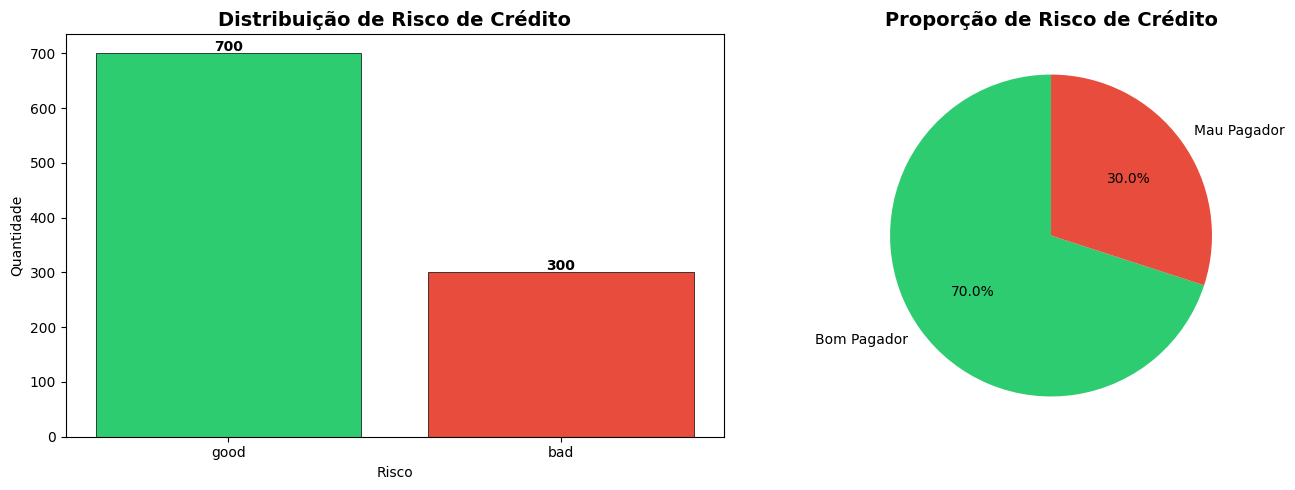

Gráfico salvo!


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

risk_counts = df['Risk'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(risk_counts.index, risk_counts.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Distribuição de Risco de Crédito', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Risco')
axes[0].set_ylabel('Quantidade')
for i, v in enumerate(risk_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(risk_counts.values, labels=['Bom Pagador', 'Mau Pagador'],
            colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proporção de Risco de Crédito', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('distribuicao_risco.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo!')

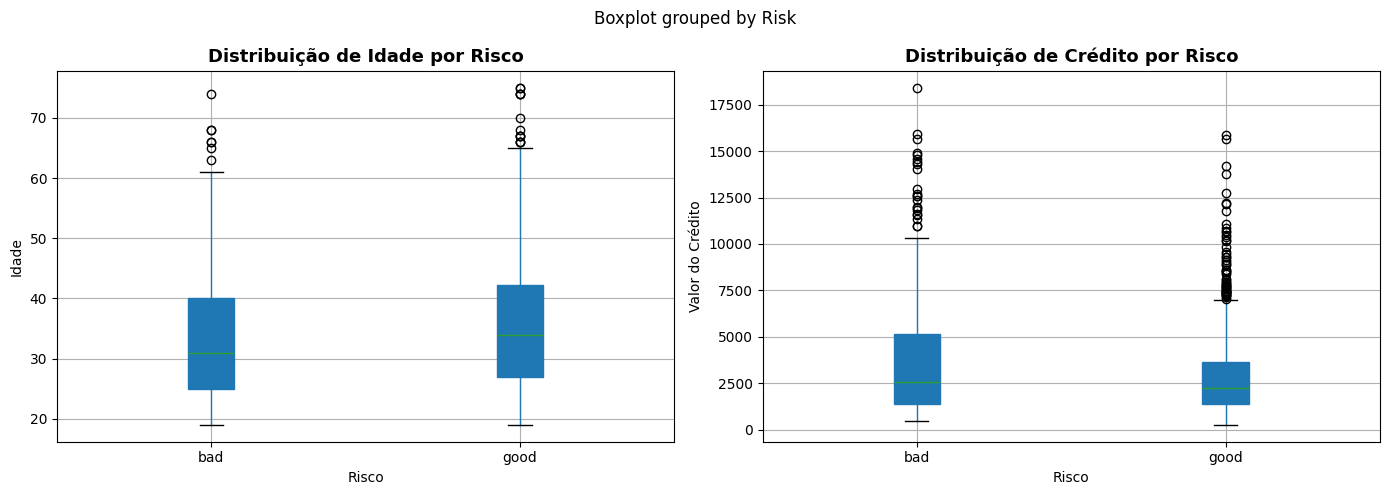

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.boxplot(column='Age', by='Risk', ax=axes[0], patch_artist=True)
axes[0].set_title('Distribuição de Idade por Risco', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Risco')
axes[0].set_ylabel('Idade')

df.boxplot(column='Credit amount', by='Risk', ax=axes[1], patch_artist=True)
axes[1].set_title('Distribuição de Crédito por Risco', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Risco')
axes[1].set_ylabel('Valor do Crédito')

plt.tight_layout()
plt.savefig('analise_exploratoria.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Preparação dos Dados

In [24]:
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

if 'Unnamed: 0' in df_model.columns:
    df_model.drop('Unnamed: 0', axis=1, inplace=True)

for col in df_model.columns:
    if df_model[col].dtype.name == 'category':
        df_model[col] = df_model[col].astype(str)

for col in df_model.columns:
    if df_model[col].dtype == 'object':
        df_model[col] = df_model[col].fillna(df_model[col].mode()[0])
    else:
        df_model[col] = df_model[col].fillna(df_model[col].median())

le = LabelEncoder()
for col in df_model.columns:
    if df_model[col].dtype == 'object':
        df_model[col] = le.fit_transform(df_model[col])

print('Tipos após codificação:')
print(df_model.dtypes)
print(f'\nShape: {df_model.shape}')

X = df_model.drop('Risk', axis=1)
y = df_model['Risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'\nTreino: {X_train.shape[0]} amostras')
print(f'Teste:  {X_test.shape[0]} amostras')

Tipos após codificação:
Age                 int64
Sex                 int64
Job                 int64
Housing             int64
Saving accounts     int64
Checking account    int64
Credit amount       int64
Duration            int64
Purpose             int64
Risk                int64
dtype: object

Shape: (1000, 10)

Treino: 800 amostras
Teste:  200 amostras


## 5. Parte 1 — Modelo Preditivo: Random Forest
Random Forest é um método de ensemble que cria múltiplas árvores de decisão e combina seus resultados para obter uma previsão mais robusta e precisa.

In [25]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)

acc_rf  = accuracy_score(y_test, y_pred_rf)
f1_rf   = f1_score(y_test, y_pred_rf, average='weighted')
prec_rf = precision_score(y_test, y_pred_rf, average='weighted')
rec_rf  = recall_score(y_test, y_pred_rf, average='weighted')

print('=== Random Forest ===')
print(f'Acurácia:  {acc_rf:.4f} ({acc_rf*100:.2f}%)')
print(f'F1-Score:  {f1_rf:.4f}')
print(f'Precisão:  {prec_rf:.4f}')
print(f'Revocação: {rec_rf:.4f}')
print('\nRelatório completo:')
print(classification_report(y_test, y_pred_rf, target_names=['Mau Pagador', 'Bom Pagador']))

=== Random Forest ===
Acurácia:  0.7300 (73.00%)
F1-Score:  0.7165
Precisão:  0.7134
Revocação: 0.7300

Relatório completo:
              precision    recall  f1-score   support

 Mau Pagador       0.57      0.42      0.48        60
 Bom Pagador       0.78      0.86      0.82       140

    accuracy                           0.73       200
   macro avg       0.67      0.64      0.65       200
weighted avg       0.71      0.73      0.72       200



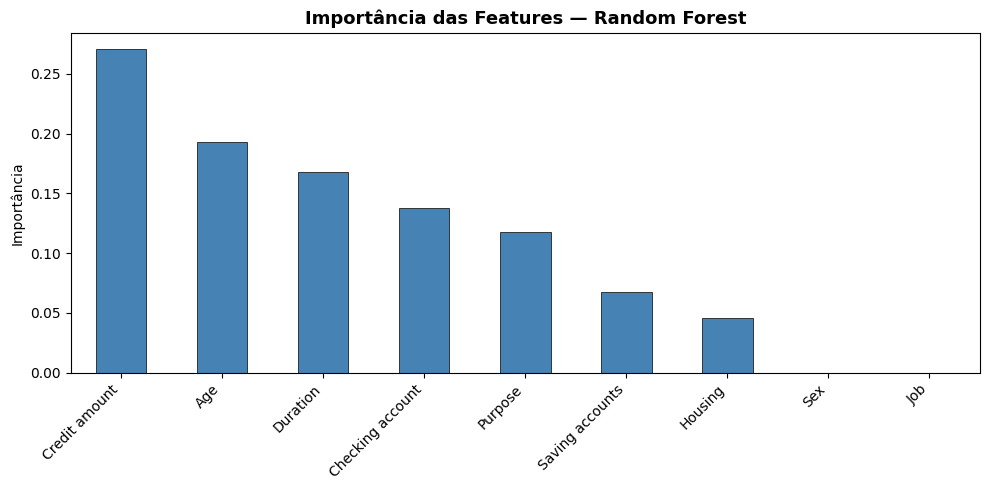

In [26]:
# Importância das features
feature_importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
feature_importances.plot(kind='bar', color='steelblue', edgecolor='black', linewidth=0.5)
plt.title('Importância das Features — Random Forest', fontsize=13, fontweight='bold')
plt.ylabel('Importância')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('random_forest_features.png', dpi=150, bbox_inches='tight')
plt.show()

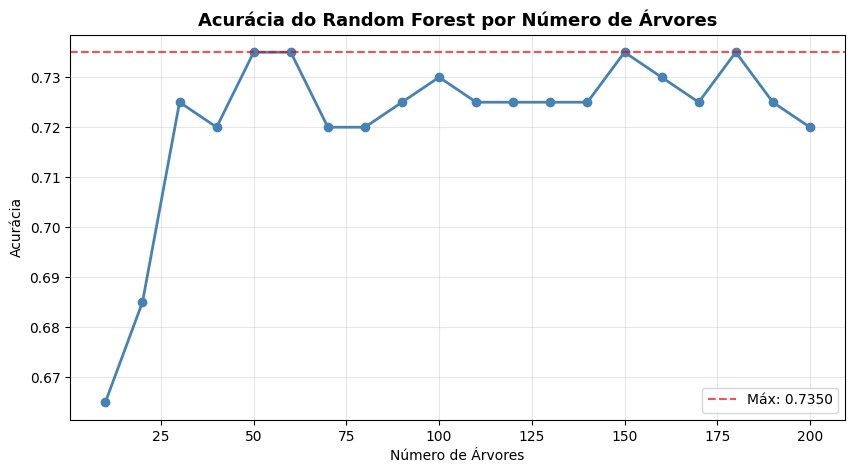

In [27]:
# Curva de acurácia por número de árvores
n_trees = range(10, 201, 10)
acc_scores = []

for n in n_trees:
    rf_temp = RandomForestClassifier(n_estimators=n, random_state=42)
    rf_temp.fit(X_train_scaled, y_train)
    acc_scores.append(accuracy_score(y_test, rf_temp.predict(X_test_scaled)))

plt.figure(figsize=(10, 5))
plt.plot(n_trees, acc_scores, marker='o', color='steelblue', linewidth=2)
plt.axhline(y=max(acc_scores), color='red', linestyle='--', alpha=0.7, label=f'Máx: {max(acc_scores):.4f}')
plt.title('Acurácia do Random Forest por Número de Árvores', fontsize=13, fontweight='bold')
plt.xlabel('Número de Árvores')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('curva_acuracia_rf.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Parte 2 — Modelo Preditivo: SVM (Support Vector Machine)
SVM é um algoritmo supervisionado que encontra o hiperplano de maior margem que separa as classes. Com o kernel RBF (Radial Basis Function), é capaz de capturar relações não-lineares nos dados.

In [28]:
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42, probability=True)
svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)

acc_svm  = accuracy_score(y_test, y_pred_svm)
f1_svm   = f1_score(y_test, y_pred_svm, average='weighted')
prec_svm = precision_score(y_test, y_pred_svm, average='weighted')
rec_svm  = recall_score(y_test, y_pred_svm, average='weighted')

print('=== SVM (Kernel RBF) ===')
print(f'Acurácia:  {acc_svm:.4f} ({acc_svm*100:.2f}%)')
print(f'F1-Score:  {f1_svm:.4f}')
print(f'Precisão:  {prec_svm:.4f}')
print(f'Revocação: {rec_svm:.4f}')
print('\nRelatório completo:')
print(classification_report(y_test, y_pred_svm, target_names=['Mau Pagador', 'Bom Pagador']))

=== SVM (Kernel RBF) ===
Acurácia:  0.7350 (73.50%)
F1-Score:  0.7082
Precisão:  0.7142
Revocação: 0.7350

Relatório completo:
              precision    recall  f1-score   support

 Mau Pagador       0.61      0.33      0.43        60
 Bom Pagador       0.76      0.91      0.83       140

    accuracy                           0.73       200
   macro avg       0.68      0.62      0.63       200
weighted avg       0.71      0.73      0.71       200



## 7. Parte 3 — Modelo Descritivo: K-Means Clustering
K-Means é um algoritmo de agrupamento não supervisionado que segmenta os clientes em grupos com perfis similares, sem usar a variável alvo. Utilizamos o Método do Cotovelo para determinar K=3.

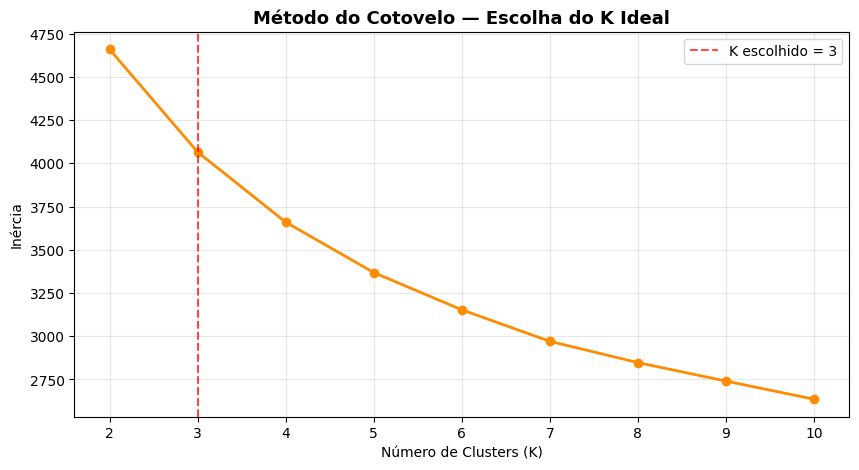

In [29]:
X_cluster = X_train_scaled.copy()
inertias = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_range, inertias, marker='o', color='darkorange', linewidth=2)
plt.axvline(x=3, color='red', linestyle='--', alpha=0.7, label='K escolhido = 3')
plt.title('Método do Cotovelo — Escolha do K Ideal', fontsize=13, fontweight='bold')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('metodo_cotovelo.png', dpi=150, bbox_inches='tight')
plt.show()

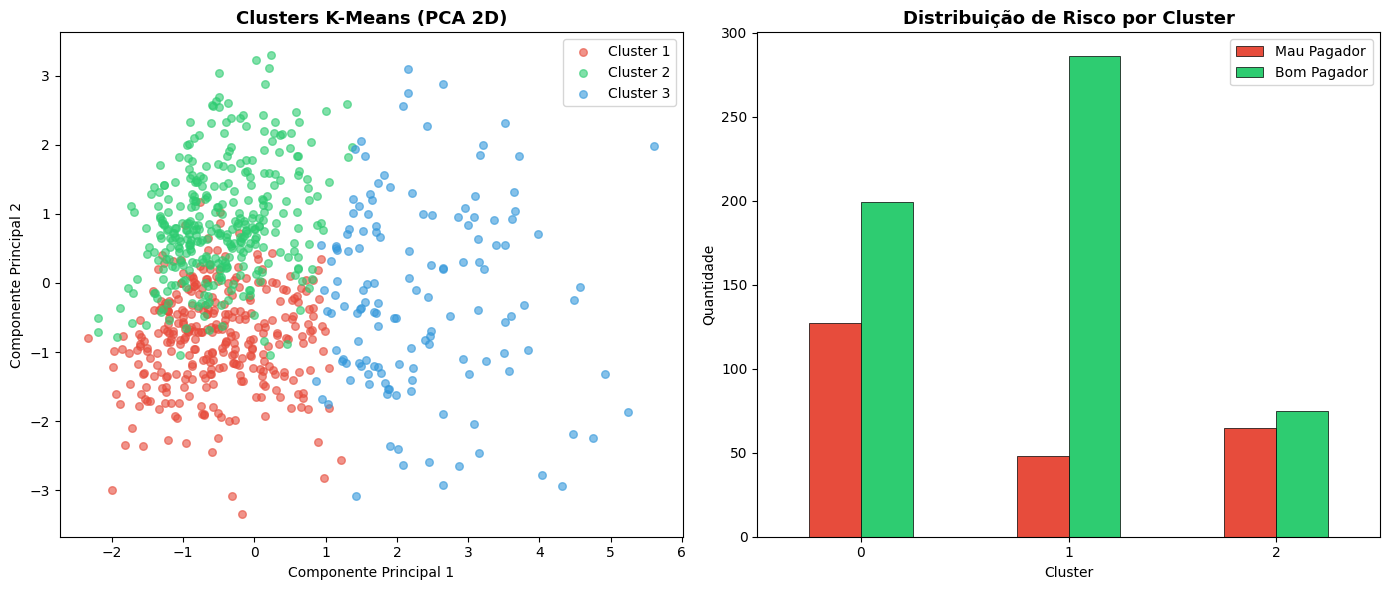

Distribuição de risco por cluster:
Risk       0    1
Cluster          
0        127  199
1         48  286
2         65   75


In [30]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_cluster)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors_cluster = ['#e74c3c', '#2ecc71', '#3498db']
for i in range(3):
    mask = clusters == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=colors_cluster[i], label=f'Cluster {i+1}',
                   alpha=0.6, s=30)
axes[0].set_title('Clusters K-Means (PCA 2D)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Componente Principal 1')
axes[0].set_ylabel('Componente Principal 2')
axes[0].legend()

df_cluster = pd.DataFrame({'Cluster': clusters, 'Risk': y_train.values})
cluster_risk = df_cluster.groupby(['Cluster', 'Risk']).size().unstack(fill_value=0)
cluster_risk.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#2ecc71'],
                  edgecolor='black', linewidth=0.5)
axes[1].set_title('Distribuição de Risco por Cluster', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Quantidade')
axes[1].legend(['Mau Pagador', 'Bom Pagador'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('kmeans_resultados.png', dpi=150, bbox_inches='tight')
plt.show()

print('Distribuição de risco por cluster:')
print(cluster_risk)

In [31]:
df_perfil = pd.DataFrame(X_train, columns=X.columns)
df_perfil['Cluster'] = clusters
perfil_medio = df_perfil.groupby('Cluster')[['Age', 'Credit amount', 'Duration']].mean()
perfil_medio.columns = ['Idade Média', 'Crédito Médio', 'Duração Média']
print('Perfil médio por cluster:')
print(perfil_medio.round(2))

Perfil médio por cluster:
         Idade Média  Crédito Médio  Duração Média
Cluster                                           
0              30.33        2335.04          17.63
1              39.59        2088.56          16.21
2              37.14        7784.79          39.29


## 8. Comparação dos Modelos: Random Forest vs SVM

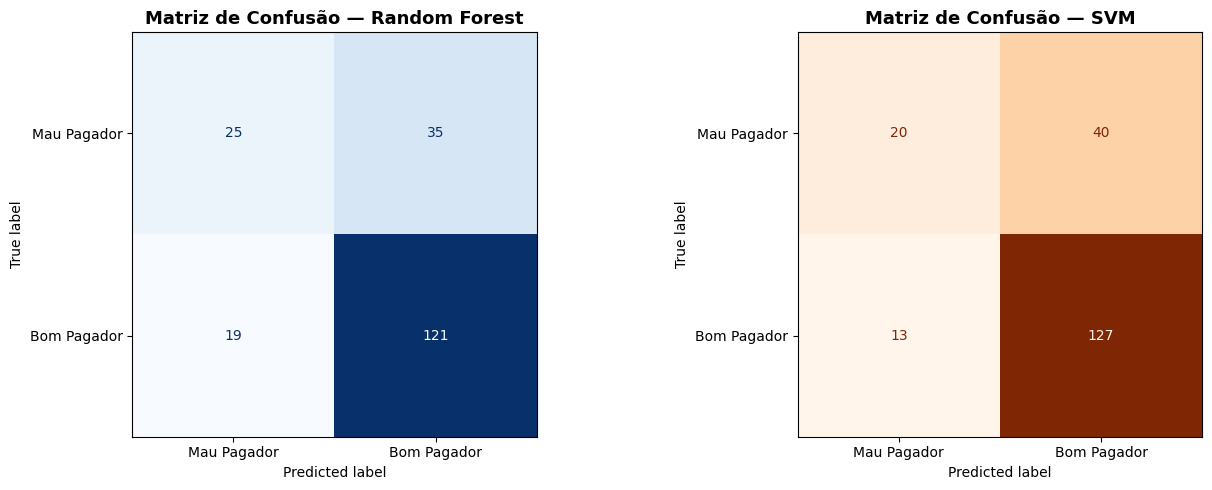

In [32]:
# Matrizes de confusão lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_rf),
    display_labels=['Mau Pagador', 'Bom Pagador']
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusão — Random Forest', fontsize=13, fontweight='bold')

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_svm),
    display_labels=['Mau Pagador', 'Bom Pagador']
).plot(ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title('Matriz de Confusão — SVM', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('matrizes_confusao.png', dpi=150, bbox_inches='tight')
plt.show()

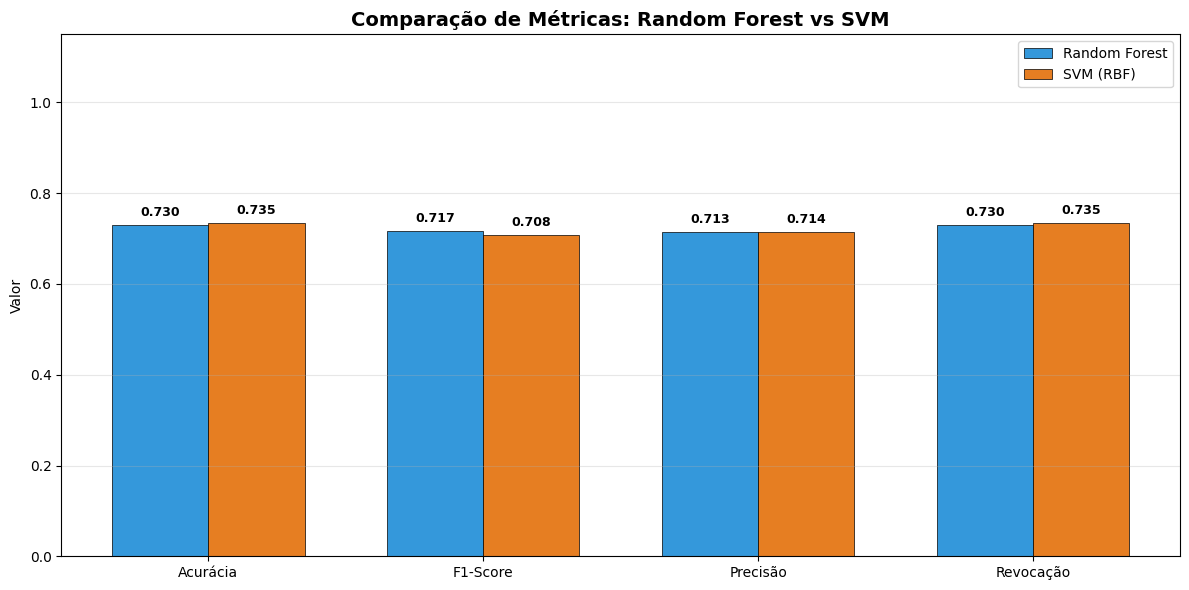

In [33]:
# Gráfico comparativo de métricas
metricas = ['Acurácia', 'F1-Score', 'Precisão', 'Revocação']
valores_rf  = [acc_rf,  f1_rf,  prec_rf,  rec_rf]
valores_svm = [acc_svm, f1_svm, prec_svm, rec_svm]

x = np.arange(len(metricas))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, valores_rf,  width, label='Random Forest', color='#3498db', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x + width/2, valores_svm, width, label='SVM (RBF)',     color='#e67e22', edgecolor='black', linewidth=0.5)

ax.set_title('Comparação de Métricas: Random Forest vs SVM', fontsize=14, fontweight='bold')
ax.set_ylabel('Valor')
ax.set_ylim(0, 1.15)
ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('comparacao_rf_svm.png', dpi=150, bbox_inches='tight')
plt.show()

In [34]:
# Tabela comparativa final
resultados = pd.DataFrame({
    'Modelo':    ['Random Forest', 'SVM (RBF)', 'K-Means'],
    'Tipo':      ['Supervisionado (Preditivo)', 'Supervisionado (Preditivo)', 'Não Supervisionado (Descritivo)'],
    'Acurácia':  [f'{acc_rf*100:.2f}%',  f'{acc_svm*100:.2f}%', 'N/A'],
    'F1-Score':  [f'{f1_rf:.4f}',        f'{f1_svm:.4f}',       'N/A'],
    'Precisão':  [f'{prec_rf:.4f}',      f'{prec_svm:.4f}',     'N/A'],
    'Revocação': [f'{rec_rf:.4f}',       f'{rec_svm:.4f}',      'N/A'],
    'Objetivo':  ['Classificar risco', 'Classificar risco', 'Segmentar perfis']
})

print('=== Comparação Final dos Modelos ===')
print(resultados.to_string(index=False))

=== Comparação Final dos Modelos ===
       Modelo                            Tipo Acurácia F1-Score Precisão Revocação          Objetivo
Random Forest      Supervisionado (Preditivo)   73.00%   0.7165   0.7134    0.7300 Classificar risco
    SVM (RBF)      Supervisionado (Preditivo)   73.50%   0.7082   0.7142    0.7350 Classificar risco
      K-Means Não Supervisionado (Descritivo)      N/A      N/A      N/A       N/A  Segmentar perfis


## 9. Salvando os Modelos Treinados

In [35]:
import joblib

joblib.dump(rf,     'modelo_random_forest.pkl')
joblib.dump(svm,    'modelo_svm.pkl')
joblib.dump(kmeans, 'modelo_kmeans.pkl')
joblib.dump(scaler, 'scaler.pkl')

print('Modelos salvos com sucesso!')
print('Arquivos gerados:')
print('  - modelo_random_forest.pkl')
print('  - modelo_svm.pkl')
print('  - modelo_kmeans.pkl')
print('  - scaler.pkl')

Modelos salvos com sucesso!
Arquivos gerados:
  - modelo_random_forest.pkl
  - modelo_svm.pkl
  - modelo_kmeans.pkl
  - scaler.pkl


In [37]:
from google.colab import files

files.download('modelo_svm.pkl')
files.download('comparacao_rf_svm.png')
files.download('matrizes_confusao.png')
files.download('random_forest_features.png')
files.download('trabalho_ia_credito_1.ipynb')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

FileNotFoundError: Cannot find file: trabalho_ia_credito_1.ipynb

## 10. Conclusão

### Random Forest (Parte 1 — Modelo Preditivo)
O Random Forest demonstrou bom desempenho na classificação de risco de crédito. Com 100 árvores de decisão combinadas, o modelo identificou padrões complexos nos dados. As features mais importantes foram **Duration**, **Credit amount** e **Age**.

### SVM — Support Vector Machine (Parte 2 — Modelo Preditivo)
O SVM com kernel RBF é um algoritmo baseado em margens máximas de separação entre classes. Ambos os modelos foram treinados e avaliados com as mesmas condições (mesmo split, mesmo scaler), permitindo uma comparação justa. A comparação das métricas revela as diferenças de desempenho entre as abordagens de ensemble e de margem máxima.

### K-Means (Parte 3 — Modelo Descritivo)
O K-Means identificou 3 perfis distintos de clientes: clientes jovens com créditos pequenos e curta duração, clientes de meia-idade com créditos médios, e clientes com histórico de créditos grandes e longa duração. Essa segmentação é complementar aos modelos preditivos e oferece insights estratégicos.

### Comparação
Random Forest e SVM são ambos modelos supervisionados e comparáveis diretamente pelas mesmas métricas (acurácia, F1, precisão, revocação). O K-Means, por ser não supervisionado, não entra nessa comparação mas complementa a análise com segmentação de perfis.